### Assignment 01
### 258828H

#### Question 01

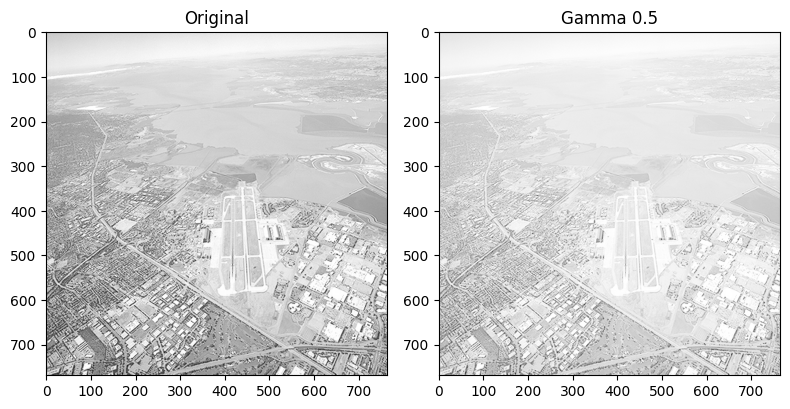

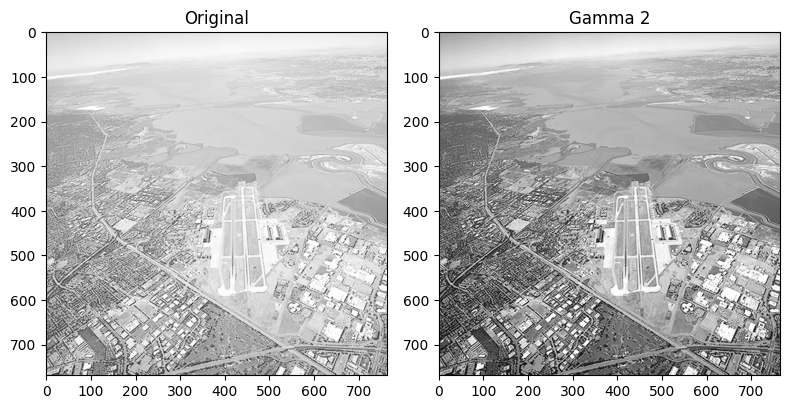

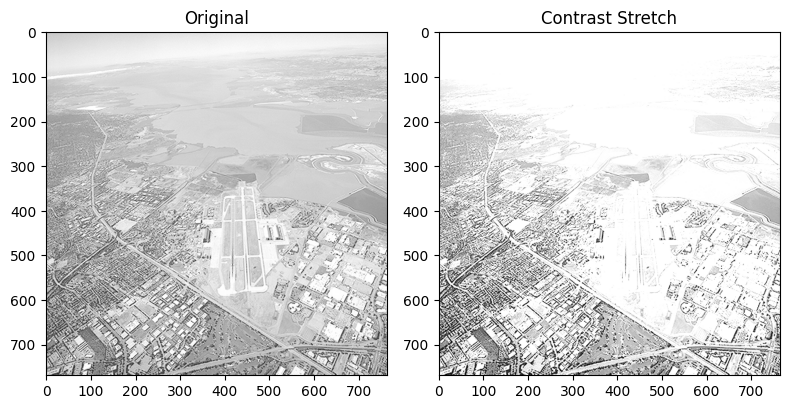

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os

# Create output folder
os.makedirs('outputs', exist_ok=True)

img = cv2.imread('images/runway.png', 0)

img = img / 255.0

# (a)
gamma_05 = np.power(img, 0.5)
cv2.imwrite('outputs/q1_gamma_05.png', (gamma_05*255).astype('uint8'))

# --------- COMPARISON 1 (Original vs Gamma 0.5) ----------
plt.figure(figsize=(8,4))

plt.subplot(1,2,1)
plt.title('Original')
plt.imshow(img, cmap='gray')

plt.subplot(1,2,2)
plt.title('Gamma 0.5')
plt.imshow(gamma_05, cmap='gray')

plt.tight_layout()
plt.savefig('outputs/q1_compare_a.png')
plt.show()

# (b)
gamma_2 = np.power(img, 2)
cv2.imwrite('outputs/q1_gamma_2.png', (gamma_2*255).astype('uint8'))

# --------- COMPARISON 2 (Original vs Gamma 2) ----------
plt.figure(figsize=(8,4))

plt.subplot(1,2,1)
plt.title('Original')
plt.imshow(img, cmap='gray')

plt.subplot(1,2,2)
plt.title('Gamma 2')
plt.imshow(gamma_2, cmap='gray')

plt.tight_layout()
plt.savefig('outputs/q1_compare_b.png')
plt.show()

# (c)
r1, r2 = 0.2, 0.8
cs = np.clip((img - r1)/(r2 - r1), 0, 1)
cv2.imwrite('outputs/q1_contrast.png', (cs*255).astype('uint8'))

# --------- COMPARISON 3 (Original vs Contrast) ----------
plt.figure(figsize=(8,4))

plt.subplot(1,2,1)
plt.title('Original')
plt.imshow(img, cmap='gray')

plt.subplot(1,2,2)
plt.title('Contrast Stretch')
plt.imshow(cs, cmap='gray')

plt.tight_layout()
plt.savefig('outputs/q1_compare_c.png')
plt.show()

#### Question 02

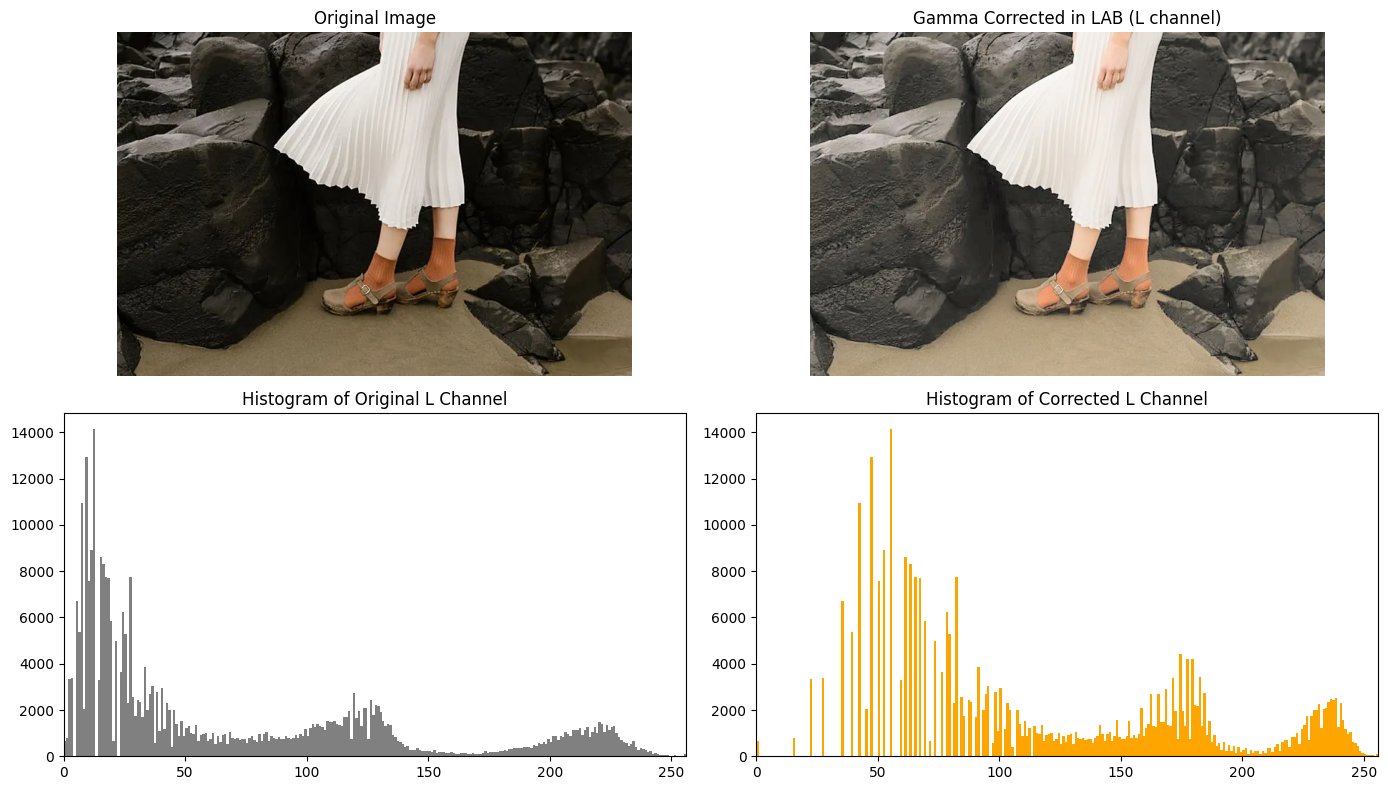

In [4]:
img_bgr = cv2.imread('images/Image for gamma correction.webp')
img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

# (a)
lab = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2LAB)
L, a, b = cv2.split(lab)

gamma = 0.5
L_norm = L / 255.0
L_gamma = np.power(L_norm, gamma)
L_gamma = np.clip(L_gamma * 255, 0, 255).astype(np.uint8)

lab_gamma = cv2.merge([L_gamma, a, b])
img_lab_gamma = cv2.cvtColor(lab_gamma, cv2.COLOR_LAB2RGB)

cv2.imwrite('outputs/q2_original.png', cv2.cvtColor(img_rgb, cv2.COLOR_RGB2BGR))
cv2.imwrite('outputs/q2_lab_gamma.png', cv2.cvtColor(img_lab_gamma, cv2.COLOR_RGB2BGR))

# (b)
plt.figure(figsize=(14, 8))

plt.subplot(2, 2, 1)
plt.title('Original Image')
plt.imshow(img_rgb)
plt.axis('off')

plt.subplot(2, 2, 2)
plt.title('Gamma Corrected in LAB (L channel)')
plt.imshow(img_lab_gamma)
plt.axis('off')

plt.subplot(2, 2, 3)
plt.title('Histogram of Original L Channel')
plt.hist(L.ravel(), bins=256, range=(0, 256), color='gray')
plt.xlim([0, 256])

plt.subplot(2, 2, 4)
plt.title('Histogram of Corrected L Channel')
plt.hist(L_gamma.ravel(), bins=256, range=(0, 256), color='orange')
plt.xlim([0, 256])

plt.tight_layout()
plt.savefig('outputs/q2_lab_gamma_comparison.png')
plt.show()

#### Question 03

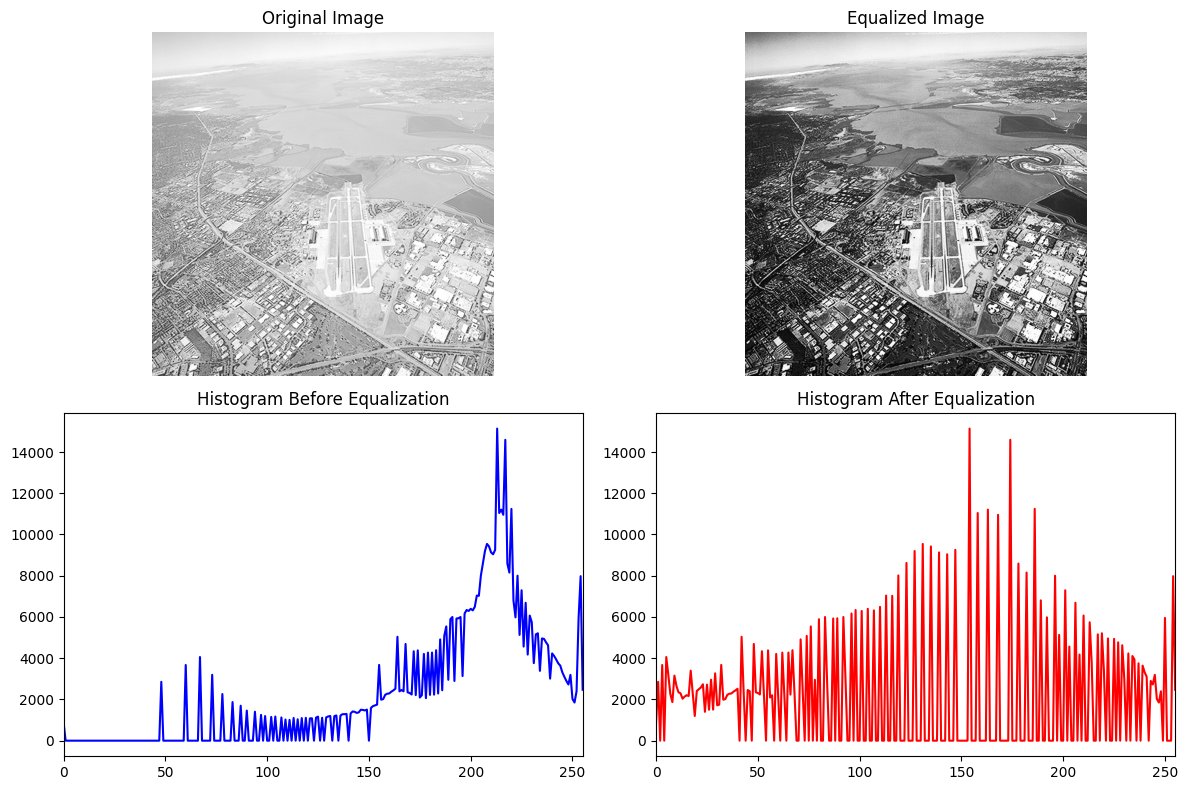

In [6]:
def my_hist_equalization(image):
    hist = np.zeros(256, dtype=np.int32)
    for pixel in image.ravel():
        hist[pixel] += 1

    cdf = np.cumsum(hist)
    cdf_min = cdf[np.nonzero(cdf)][0]
    total_pixels = image.size

    lut = np.round((cdf - cdf_min) / (total_pixels - cdf_min) * 255)
    lut = np.clip(lut, 0, 255).astype(np.uint8)

    equalized = lut[image]
    return equalized, hist

img_q3 = cv2.imread('images/runway.png', 0)
equalized_img, hist_before = my_hist_equalization(img_q3)
hist_after = np.bincount(equalized_img.ravel(), minlength=256)

cv2.imwrite('outputs/q3_original_runway.png', img_q3)
cv2.imwrite('outputs/q3_equalized_runway.png', equalized_img)

plt.figure(figsize=(12, 8))

plt.subplot(2, 2, 1)
plt.title('Original Image')
plt.imshow(img_q3, cmap='gray')
plt.axis('off')

plt.subplot(2, 2, 2)
plt.title('Equalized Image')
plt.imshow(equalized_img, cmap='gray')
plt.axis('off')

plt.subplot(2, 2, 3)
plt.title('Histogram Before Equalization')
plt.plot(hist_before, color='blue')
plt.xlim([0, 255])

plt.subplot(2, 2, 4)
plt.title('Histogram After Equalization')
plt.plot(hist_after, color='red')
plt.xlim([0, 255])

plt.tight_layout()
plt.savefig('outputs/q3_histogram_equalization.png')
plt.show()

#### Question 04

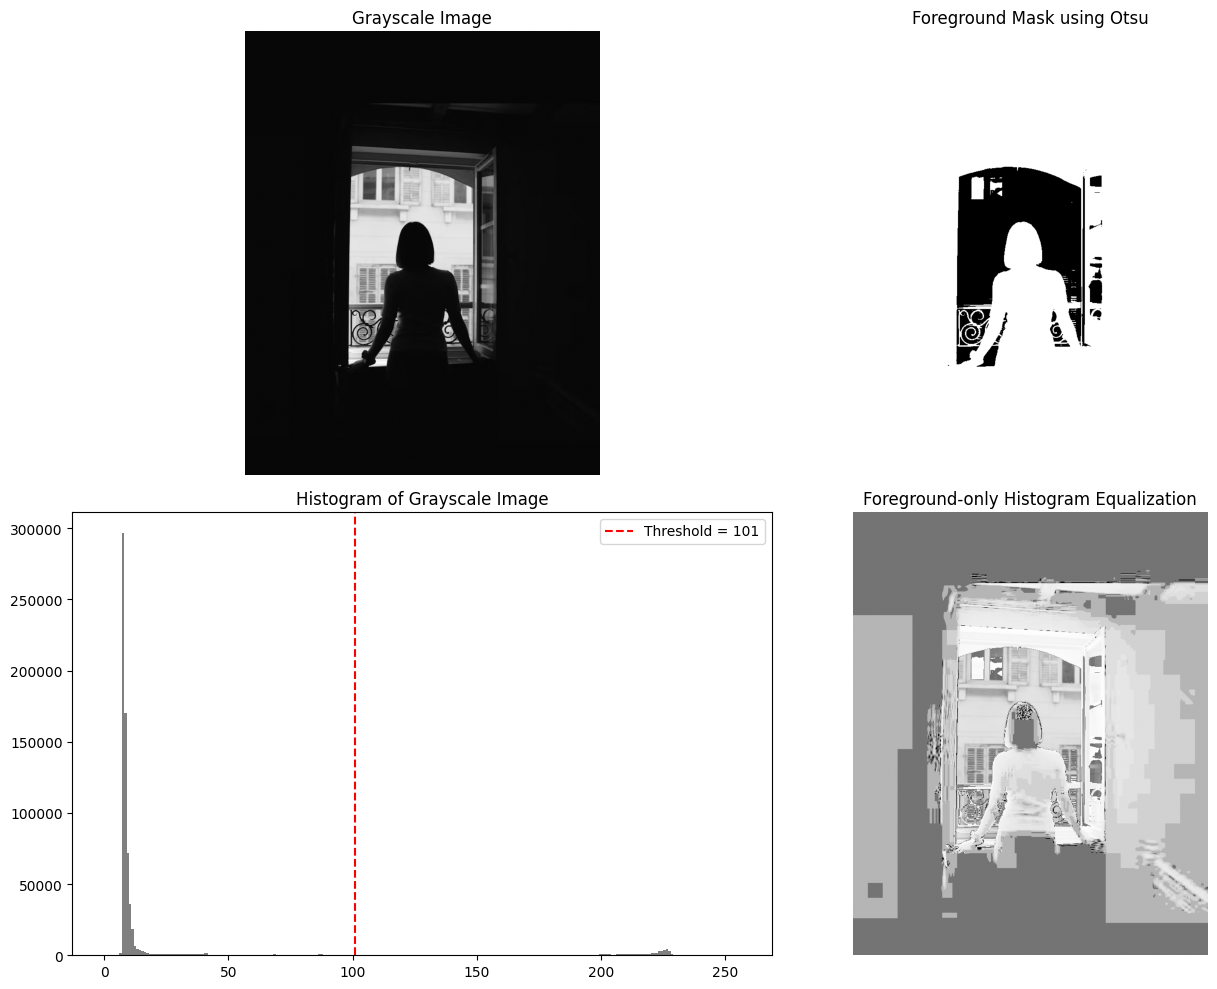

In [9]:
from PIL import Image

def masked_hist_equalization(image, mask):
    foreground_pixels = image[mask > 0]
    hist = np.bincount(foreground_pixels, minlength=256)
    cdf = np.cumsum(hist)
    cdf_nonzero = cdf[cdf > 0]
    cdf_min = cdf_nonzero[0]
    lut = np.round((cdf - cdf_min) / (foreground_pixels.size - cdf_min) * 255)
    lut = np.clip(lut, 0, 255).astype(np.uint8)

    result = image.copy()
    result[mask > 0] = lut[image[mask > 0]]
    return result

img_q4 = Image.open('images/Woman standing in front of an open door..avif').convert('L')
gray_q4 = np.array(img_q4)

# (a) Otsu thresholding
threshold_value, otsu_binary = cv2.threshold(gray_q4, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

foreground_mask = np.where(gray_q4 <= threshold_value, 255, 0).astype(np.uint8)

# (b) 
equalized_foreground = masked_hist_equalization(gray_q4, foreground_mask)

cv2.imwrite('outputs/q4_grayscale.png', gray_q4)
cv2.imwrite('outputs/q4_foreground_mask.png', foreground_mask)
cv2.imwrite('outputs/q4_foreground_equalized.png', equalized_foreground)

plt.figure(figsize=(14, 10))

plt.subplot(2, 2, 1)
plt.title('Grayscale Image')
plt.imshow(gray_q4, cmap='gray')
plt.axis('off')

plt.subplot(2, 2, 2)
plt.title('Foreground Mask using Otsu')
plt.imshow(foreground_mask, cmap='gray')
plt.axis('off')

plt.subplot(2, 2, 3)
plt.title('Histogram of Grayscale Image')
plt.hist(gray_q4.ravel(), bins=256, range=(0, 256), color='gray')
plt.axvline(threshold_value, color='red', linestyle='--', label=f'Threshold = {threshold_value:.0f}')
plt.legend()

plt.subplot(2, 2, 4)
plt.title('Foreground-only Histogram Equalization')
plt.imshow(equalized_foreground, cmap='gray')
plt.axis('off')

plt.tight_layout()
plt.savefig('outputs/q4_otsu_and_equalization.png')
plt.show()

#### Question 05

Normalized 5x5 Gaussian kernel for sigma = 2:
[[0.023247 0.033824 0.038328 0.033824 0.023247]
 [0.033824 0.049214 0.055766 0.049214 0.033824]
 [0.038328 0.055766 0.063191 0.055766 0.038328]
 [0.033824 0.049214 0.055766 0.049214 0.033824]
 [0.023247 0.033824 0.038328 0.033824 0.023247]]
Sum of kernel = 1.0


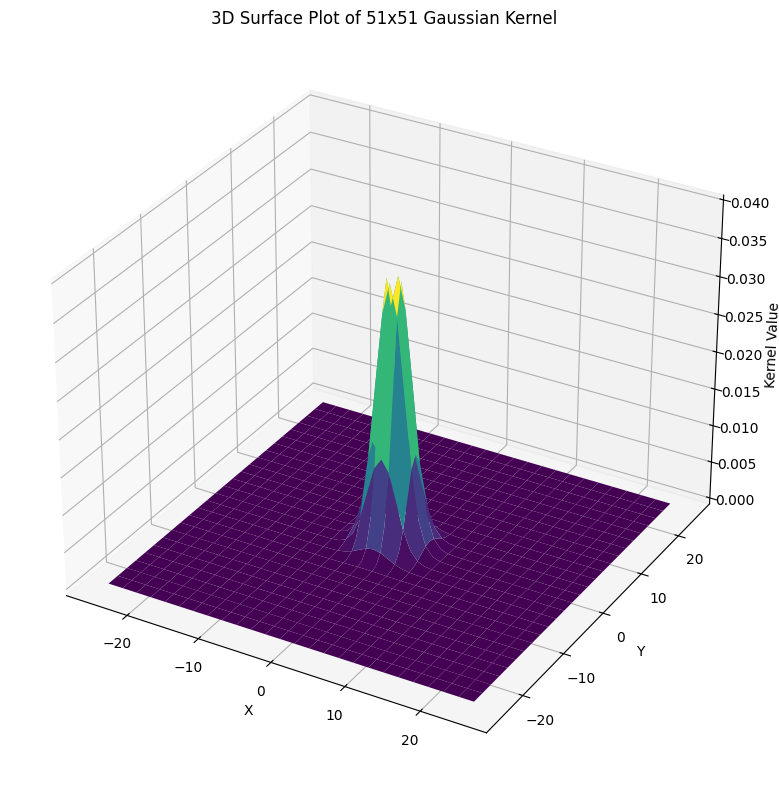

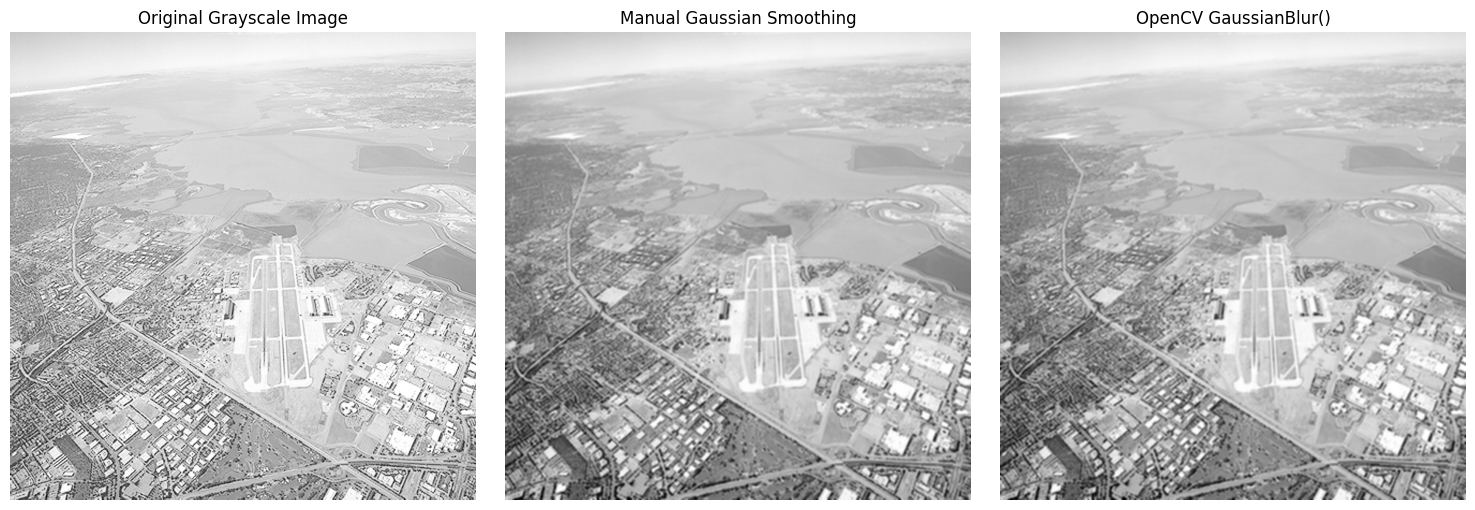

In [11]:
from mpl_toolkits.mplot3d import Axes3D

def gaussian_kernel(size, sigma):
    ax = np.arange(-(size // 2), size // 2 + 1)
    xx, yy = np.meshgrid(ax, ax)
    kernel = np.exp(-(xx**2 + yy**2) / (2 * sigma**2))
    kernel = kernel / np.sum(kernel)
    return kernel

def manual_convolution(image, kernel):
    k = kernel.shape[0]
    pad = k // 2
    padded = np.pad(image, ((pad, pad), (pad, pad)), mode='reflect')
    output = np.zeros_like(image, dtype=np.float64)

    for i in range(image.shape[0]):
        for j in range(image.shape[1]):
            region = padded[i:i+k, j:j+k]
            output[i, j] = np.sum(region * kernel)

    return np.clip(output, 0, 255).astype(np.uint8)

# (a) Normalized 5x5 Gaussian kernel for sigma = 2
kernel_5x5 = gaussian_kernel(5, 2)
print('Normalized 5x5 Gaussian kernel for sigma = 2:')
print(np.round(kernel_5x5, 6))
print('Sum of kernel =', kernel_5x5.sum())

# (b) 51x51 Gaussian kernel visualized as a 3D surface plot
kernel_51x51 = gaussian_kernel(51, 2)
x = np.arange(-(51 // 2), 51 // 2 + 1)
y = np.arange(-(51 // 2), 51 // 2 + 1)
X, Y = np.meshgrid(x, y)

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')
ax.plot_surface(X, Y, kernel_51x51, cmap='viridis')
ax.set_title('3D Surface Plot of 51x51 Gaussian Kernel')
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Kernel Value')
plt.tight_layout()
plt.savefig('outputs/q5_gaussian_3d_surface.png')
plt.show()

# (c) Manual Gaussian smoothing using the computed kernel
img_q5 = cv2.imread('images/runway.png', 0)
manual_blur = manual_convolution(img_q5, kernel_5x5)

# (d) Gaussian smoothing using OpenCV
opencv_blur = cv2.GaussianBlur(img_q5, (5, 5), 2)

cv2.imwrite('outputs/q5_original.png', img_q5)
cv2.imwrite('outputs/q5_manual_gaussian.png', manual_blur)
cv2.imwrite('outputs/q5_opencv_gaussian.png', opencv_blur)

plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.title('Original Grayscale Image')
plt.imshow(img_q5, cmap='gray')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.title('Manual Gaussian Smoothing')
plt.imshow(manual_blur, cmap='gray')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.title('OpenCV GaussianBlur()')
plt.imshow(opencv_blur, cmap='gray')
plt.axis('off')

plt.tight_layout()
plt.savefig('outputs/q5_gaussian_comparison.png')
plt.show()